In [11]:
import numpy as np
import os 
from tqdm import tqdm
import data_preproc.data_preproc_config as data_preproc_config

In [12]:
segmap_path = 'datasets/dataset_dan/patients/0194775/segmentation_map.npy'
SEGMAP = np.load(segmap_path)



In [13]:
def combine_left_right_structs(rtstruct_value_to_name_dict):
    """
    joins the strings of the left and right structures into one string
    (e.g. 'parotid' and 'parotid' become 'parotid')
    """
    right_left_struct_names = ['_li', '_re']
    
    for key, value in rtstruct_value_to_name_dict.items():
        for side in right_left_struct_names:
            if side in value:
                rtstruct_value_to_name_dict[key] = value.replace(side, '')

    return rtstruct_value_to_name_dict

def remove_duplicates(items):
    """
    Removes duplicates from a list while preserving the order of the items
    """
    new_list = []
    for item in items:
        if item not in new_list:
            new_list.append(item)
    return new_list

def create_segmap_encoding_dictionaries(n_channels = 4):
    """
    Create dictionaries for binary encoding the segmentation map into 4 channels
    """
    # Generate all n^2 possible binary multi-hot encodings with a length of `n`
    binary_combinations_list = [list(format(i, f'0{n_channels}b')) for i in range(n_channels**2)]
    binary_combinations_list = [[int(bit) for bit in combo] for combo in binary_combinations_list]  # convert to lists of inters

    # drop the all-zero encoding (its the background class)
    binary_combinations_list = [x for x in binary_combinations_list if sum(x) != 0]
    binary_combinations_list.reverse()    # this is the list of possible binary encodings for the segmentation map [[1,1,1,1], [1,1,1,0], [1,1,0,1], ...]

    # get the 16 names and 16 int values for the structures
    structures_names_list = list(data_preproc_config.structures_values.keys())
    structures_values_list = list(data_preproc_config.structures_values.values())
    # dict of {integer: name} for the structures
    rtstruct_value_to_name_dict = dict(zip(structures_values_list, structures_names_list))

    # combine the left and right structures into one  (e.g. 'parotid_li' and 'parotid_re' become 'parotid')
    rtstruct_value_to_name_dict = combine_left_right_structs(rtstruct_value_to_name_dict)

    # get the unique structure names from that (i.e. remove the double 'parotid' and 'parotid' from the list of structure names)
    unique_struct_names_list = remove_duplicates(list(rtstruct_value_to_name_dict.values()))  

    # a dict of {structure_name: binary encoding} for the unique structures that are left
    length = len(unique_struct_names_list)
    print(length)
    struct_name_to_encoding_dict = dict(zip(unique_struct_names_list, binary_combinations_list[:length]))
    print(struct_name_to_encoding_dict.keys())
    
    # make a dictionary that maps the 16 rtstruct values to the binary encodings
    struct_value_to_encoding_dict = {val: struct_name_to_encoding_dict[name] for val, name in rtstruct_value_to_name_dict.items()}

    struct_full_name_to_encoding_dict = {name: encoding for name, encoding in zip(structures_names_list, list(struct_value_to_encoding_dict.values()))}
    
   
    # return two dictionaries: 
    # 1. maps the structure names (strings) to the binary encodings =   {'submandibularis_li': [1, 1, 1, 0]}
    # 2. maps the structure values to the binary encodings          =   {3 : [1, 1, 1, 0]}
    return struct_value_to_encoding_dict, struct_full_name_to_encoding_dict


In [14]:
n_channels = 4

struct_value_to_encoding_dict, struct_name_to_encoding_dict = create_segmap_encoding_dictionaries(n_channels = 4)

13
dict_keys(['parotis', 'submandibularis', 'crico', 'thyroid', 'mandible', 'glotticarea', 'oralcavity_ext', 'supraglottic', 'buccalmucosa', 'pcm_inf', 'pcm_med', 'pcm_sup', 'esophagus_cerv'])


# Loop through dataset_full and create the binarised segmaps

In [15]:
save_dir_dataset_full = data_preproc_config.save_dir_dataset_full

import config as cfg
save_dir_dataset_full = cfg.patients_data_dir
save_dir_dataset_full = '\\\\zkh\\appdata\\RTDicom\\Projectline_HNC_modelling\\Users\\Daniel MacRae\\DL_NTCP_Multitox\\datasets\\MT_dataset\\patients'
patient_folders = os.listdir(save_dir_dataset_full)

In [16]:
save_dir_dataset_full

'\\\\zkh\\appdata\\RTDicom\\Projectline_HNC_modelling\\Users\\Daniel MacRae\\DL_NTCP_Multitox\\datasets\\MT_dataset\\patients'

In [17]:
len(patient_folders)

1168

In [18]:
for folder in tqdm(patient_folders):
    load_segmap_dir = os.path.join(save_dir_dataset_full, folder, data_preproc_config.filename_segmentation_map_npy)
    save_encoded_segmap_dir = os.path.join(save_dir_dataset_full, folder, data_preproc_config.filename_multihot_encoded_segmentation_map_npy)

    # load the segmentation map (also remove the first dimension, which is always 1)
    #print(segmap_dir)
    SEGMAP = np.squeeze(np.load(load_segmap_dir))
    #print(SEGMAP.shape)

    # start defining the multi_hot encoding of the segmentation map
    new_size = (n_channels, *SEGMAP.shape)
    NEW_SEGMAP = np.zeros(new_size, dtype='int16')

    for i in range(1, 17):
        template = SEGMAP == i
        binary_encoding = struct_value_to_encoding_dict[i]

        #print(binary_encoding)

        for j in range(n_channels):
            NEW_SEGMAP[j][template] = binary_encoding[j]

    np.save(save_encoded_segmap_dir, NEW_SEGMAP)

    """
    lower_limit = 0
    upper_limit = 16
    segmap_cmap = plt.cm.hsv
    cmaplist = [segmap_cmap(i) for i in range(segmap_cmap.N)]
    cmaplist[0] = (0, 0, 0, 1.0) # force the first color entry to be black
    segmap_cmap = mpl.colors.LinearSegmentedColormap.from_list(
            'SEGMAP cmap', cmaplist, segmap_cmap.N)
    bounds = np.linspace(lower_limit, upper_limit, segmap_cmap.N)
    segmap_norm = mpl.colors.BoundaryNorm(bounds, segmap_cmap.N)

    SEGMAP = np.expand_dims(SEGMAP, axis=0)

    steps = 10
    stepsize = NEW_SEGMAP.shape[-1] // steps

    width = NEW_SEGMAP.shape[0] + 1
    height = steps

    # Create a figure and a set of subplots
    fig, axs = plt.subplots(height, width, figsize=(width*2, height*2)) # 10 rows, 4 columns

    # Iterate over the slices and plot each one
    for i, ax_row in enumerate(axs):
        for j, ax in enumerate(ax_row):
            # Select a slice from the 4D array
            if j == 0:
                slice_2d = SEGMAP[j, i*stepsize, :, :]
                # Plot the 2D slice
                ax.imshow(slice_2d, cmap=segmap_cmap, norm=segmap_norm, interpolation='none')
                ax.set_title(f'Original, Slice {i+1}')
            else:
                j -= 1
                slice_2d = NEW_SEGMAP[j, i*stepsize, :, :]
                # Plot the 2D slice
                ax.imshow(slice_2d, cmap='gray', interpolation='none')
                ax.set_title(f'Dimension {j+1}, Slice {i+1}')
            ax.axis('off') # Hide axis for cleaner look

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()
    """
    

100%|██████████| 1168/1168 [07:28<00:00,  2.61it/s]


In [8]:
import pandas as pd

df = pd.read_excel('datasets/MT_dataset/patients_all_features.xlsx')

df.columns

Index(['PatientID', 'Sex', 'Age', 'CT+C_available', 'CT_Artefact', 'Loctum2',
       'Photons', 'T_stage', 'N_stage', 'Smoking', 'P16', 'WHO',
       'Xerostomia_BSL', 'Xerostomia_W01', 'Aspiration_BSL', 'Aspiration_W01',
       'Sticky_BSL', 'Sticky_W01', 'Taste_BSL', 'Taste_W01', 'Dysphagia_BSL',
       'Dysphagia_W01', 'Xerostomia_M06', 'Xerostomia_M12', 'Xerostomia_M18',
       'Aspiration_M06', 'Aspiration_M12', 'Aspiration_M18', 'Sticky_M06',
       'Sticky_M12', 'Sticky_M18', 'Taste_M06', 'Taste_M12', 'Taste_M18',
       'Dysphagia_M06', 'Dysphagia_M12', 'Dysphagia_M18', 'Parotid_L_meandose',
       'Parotid_R_meandose', 'Parotid_meandose', 'Submandibular_L_meandose',
       'Submandibular_R_meandose', 'Submandibular_meandose',
       'PCM_Sup_meandose', 'PCM_Med_meandose', 'PCM_Inf_meandose',
       'Crico_meandose', 'Supraglottic_meandose', 'OralCavity_Ext_meandose',
       'BuccalMucosa_L_meandose', 'BuccalMucosa_R_meandose',
       'BuccalMucosa_meandose', 'TongueTop_meandos

In [9]:
df["CT+C_available"].value_counts()

CT+C_available
1.0    957
0.0    210
Name: count, dtype: int64

In [10]:
df["CT+C"].value_counts()

CT+C
1    947
0    221
Name: count, dtype: int64

In [46]:
df_folders = pd.read_csv("datasets/MT_dataset/patient_folder_types.csv", delimiter=';')

df_folders.rename(columns={"Patient_id": "PatientID"}, inplace=True)
df_folders["CT+C_available"] = df_folders["Folder"].apply(lambda x: 1 if x == "with_contrast" else 0)

df_folders["CT+C_available"].value_counts()
df_folders


,PatientID,Folder,Comments,CT+C_available
0,5680,with_contrast,NaN,1
1,20715,with_contrast,NaN,1
2,21879,with_contrast,NaN,1
3,52277,with_contrast,NaN,1
4,59896,with_contrast,NaN,1
...,...,...,...,...
1163,9949620,no_contrast,NaN,0
1164,9956433,with_contrast,NaN,1
1165,9967950,with_contrast,NaN,1
1166,9977441,with_contrast,NaN,1


In [2]:
import pandas as pd

# Assuming df1 and df2 are the two dataframes
# and 'column_name' is the column to compare
df1 = df.copy()
df2 = df_folders.copy()
# Merge the dataframes on the column_name
merged_df = pd.merge(df1, df2, on='PatientID', how='outer', suffixes=('_df1', '_df2'))

# Filter the rows where the column values are not the same
result_df = merged_df[merged_df['CT+C_available_df1'] != merged_df['CT+C_available_df2']]
result_df

result_df = result_df[['PatientID', 'CT+C_available_df1', 'CT+C_available_df2']]
result_df.rename(columns={"CT+C_available_df1": "CT+C_available_OLD", 'CT+C_available_df2' : 'CT+C_available_DANIEL'}, inplace=True)
result_df.to_excel('datasets/MT_dataset/patients_CT+C_available_comparison.xlsx', index=False)

C:\Users\MacRaeDC\AppData\Local\Temp\ipykernel_10348\463652226.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was too old on your system - pyarrow 10.0.1 is the current minimum supported version as of this release.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


NameError: name 'df' is not defined

In [ ]:
df2

,Patient_id,Folder,Comments,Patient_ID,CT+C_available
0,5680,with_contrast,NaN,5680,1
1,20715,with_contrast,NaN,20715,1
2,21879,with_contrast,NaN,21879,1
3,52277,with_contrast,NaN,52277,1
4,59896,with_contrast,NaN,59896,1
...,...,...,...,...,...
1163,9949620,no_contrast,NaN,9949620,0
1164,9956433,with_contrast,NaN,9956433,1
1165,9967950,with_contrast,NaN,9967950,1
1166,9977441,with_contrast,NaN,9977441,1


In [ ]:
df1 = pd.read_csv('h:\preprocess_MT_data\patient_folder_types.csv', delimiter=';')
df2 = pd.read_csv('H:\preprocess_MT_data_UID_FULL/patient_folder_types.csv', delimiter=';')
df1['Patient_id'] = df1['Patient_id'].astype(str).str.zfill(7)
df2['Patient_id'] = df2['Patient_id'].astype(str).str.zfill(7)

merged_df_2= pd.merge(df1, df2, on='Patient_id', how='inner', suffixes=('_df1', '_df2'))

result_df2 = merged_df_2[merged_df_2['Folder_df1'] != merged_df_2['Folder_df2']]

NameError: name 'pd' is not defined

In [77]:
result_df2

,Patient_id,Folder_df1,Comments_df1,Folder_df2,Comments_df2
67,0507025,with_contrast,NaN,no_contrast,NaN
118,0851961,with_contrast,NaN,no_contrast,NaN
271,2067099,with_contrast,NaN,no_contrast,NaN
292,2102777,with_contrast,NaN,no_contrast,NaN
540,3941688,with_contrast,NaN,no_contrast,NaN
601,4673928,with_contrast,NaN,no_contrast,NaN
651,5088300,with_contrast,NaN,no_contrast,NaN
738,5896858,with_contrast,NaN,no_contrast,NaN


In [26]:
df_folders["Folder"].value_counts()


Folder
with_contrast    946
no_contrast      222
Name: count, dtype: int64

In [29]:
len(df_folders)

1168

# check which patients do or do not have a CT+C folder

In [24]:
import os
import shutil

main_folder = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/PRI2MA/Now_Has_endpoint_for_at_least_1_toxicity"
patient_folders = [x for x in os.listdir(main_folder) if "_" not in x]
patient_folders.sort()
patient_folders

df_dict = {}

for folder in patient_folders:
    folder_path = os.path.join(main_folder, folder)
    files = os.listdir(folder_path)
    if "with_contrast" in files:
        df_dict[folder] = 1
    else:
        df_dict[folder] = 0

df_CT = pd.DataFrame.from_dict(df_dict, columns=['CT+C_available'], orient='index')
df_CT["UMCG"] = df_CT.index

In [26]:
df_CT

,CT+C_available,UMCG
0005680,1,0005680
0020715,1,0020715
0021879,1,0021879
0052277,1,0052277
0059896,1,0059896
...,...,...
9949620,0,9949620
9956433,1,9956433
9967950,1,9967950
9977441,1,9977441


In [20]:
# CITOR_REDCAP

df_CITOR = pd.read_excel("//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/Data Preprocessing/CITOR_REDCAP_clinical_data_important_variables_combined.xlsx")
df_CITOR

,UMCG,DB,RTSTART,GESLACHT,LEEFTIJD,Technique,Technique_REDCAP,Technique_check,Check2,Inplancode,...,Passed_M06,Passed_M12,Passed_M18,CT+C_planning,CT+C_available,CT_Artefact,Year_treatment_3cat,Year_treatment_2cat,Photons,Xerostomia_BSL
0,249713,CITOR143,2017-01-25,Man,74,VMAT,VMAT,1.0,NaN,HH VMAT 33 5x CBCT,...,1,1,1,0,0,1,2,1,1,1.0
1,309877,CITOR143,2017-01-09,Man,69,VMAT,VMAT,1.0,NaN,HH VMAT 35 6x PET-CT CBCT,...,1,1,1,1,1,0,2,1,1,1.0
2,402490,CITOR143,2017-01-16,Man,85,VMAT,VMAT,1.0,NaN,HH VMAT 35 5x CBCT,...,1,1,1,1,1,0,2,1,1,1.0
3,617129,CITOR143,2017-06-19,Man,58,VMAT,VMAT,1.0,NaN,HH VMAT 35 5x CBCT,...,1,1,1,0,0,0,2,1,1,1.0
4,646031,CITOR143,2016-07-04,Man,69,IMRT,VMAT,0.0,NaN,HH IMRT 35 6x CBCT,...,1,1,1,1,1,0,1,1,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1437,9859008,REDCAP,2021-12-15,Vrouw,60,Protons,Protons,1.0,NaN,HH-Primair-Standaard,...,0,0,0,0,0,0,2,1,0,1.0
1438,9905707,REDCAP,2021-12-27,Man,53,VMAT,VMAT,1.0,NaN,HH 35 GL 5x,...,0,0,0,0,0,0,2,1,1,1.0
1439,9916161,REDCAP,2015-04-28,Vrouw,65,IMRT,IMRT,1.0,NaN,HHIMRT 35 5x CBCT (wekelijks Her-CT),...,1,1,1,1,1,0,1,1,1,2.0
1440,9946201,REDCAP,2018-10-24,Vrouw,65,Protons,Protons,1.0,NaN,HH Protonen Basis met HerCT,...,1,1,1,0,1,0,2,1,0,2.0


In [33]:
df_CT['UMCG'] = df_CT["UMCG"].astype(str).str.zfill(7)
df_CITOR['UMCG'] = df_CITOR["UMCG"].astype(str).str.zfill(7)

df1 = df_CT.copy()
df2 = df_CITOR.copy()

merged_df_3= pd.merge(df1, df2, on='UMCG', how='inner', suffixes=('_df1', '_df2'))

result_df3 = merged_df_3[merged_df_3['CT+C_available_df1'] != merged_df_3['CT+C_available_df2']]
result_df3

,CT+C_available_df1,UMCG,DB,RTSTART,GESLACHT,LEEFTIJD,Technique,Technique_REDCAP,Technique_check,Check2,...,Passed_M06,Passed_M12,Passed_M18,CT+C_planning,CT+C_available_df2,CT_Artefact,Year_treatment_3cat,Year_treatment_2cat,Photons,Xerostomia_BSL
269,0,2063466,REDCAP,2018-10-31,Vrouw,71,VMAT,VMAT,1.0,NaN,...,1,1,1,0,1,0,2,1,1,1.0
334,0,2159400,REDCAP,2019-11-06,Man,76,Protons,Protons,1.0,NaN,...,1,1,1,0,1,0,2,1,0,1.0
437,0,2596991,CITOR750,2010-09-20,Man,63,IMRT,NaN,NaN,NaN,...,1,1,1,0,1,0,0,0,1,1.0
1001,1,8348176,REDCAP,2018-11-12,Vrouw,68,VMAT,VMAT,1.0,NaN,...,1,1,1,0,0,0,2,1,1,1.0


In [36]:
result_df4 = merged_df_3[merged_df_3['CT+C_available_df1'] != merged_df_3['CT+C_planning']]
result_df4

,CT+C_available_df1,UMCG,DB,RTSTART,GESLACHT,LEEFTIJD,Technique,Technique_REDCAP,Technique_check,Check2,...,Passed_M06,Passed_M12,Passed_M18,CT+C_planning,CT+C_available_df2,CT_Artefact,Year_treatment_3cat,Year_treatment_2cat,Photons,Xerostomia_BSL
1,1,0020715,REDCAP,2018-04-16,Man,56,VMAT,VMAT,1.0,NaN,...,1,1,1,0,1,0,2,1,1,1.0
4,1,0059896,REDCAP,2018-07-30,Man,51,VMAT,VMAT,1.0,NaN,...,1,1,1,0,1,0,2,1,1,1.0
13,1,0137534,REDCAP,2021-04-26,Vrouw,52,Protons,Protons,1.0,NaN,...,1,0,0,0,1,0,2,1,0,1.0
20,1,0170637,REDCAP,2020-07-22,Man,75,Protons,Protons,1.0,NaN,...,1,1,0,0,1,0,2,1,0,1.0
24,1,0194349,REDCAP,2021-03-10,Man,66,Protons,Protons,1.0,NaN,...,1,0,0,0,1,0,2,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113,1,9462318,REDCAP,2019-07-17,Man,68,VMAT,VMAT,1.0,NaN,...,1,1,1,0,1,0,2,1,1,1.0
1128,1,9577277,REDCAP,2019-03-04,Man,32,0,0,1.0,Protons,...,1,1,1,0,1,0,2,1,0,1.0
1135,1,9692367,REDCAP,2021-02-25,Vrouw,52,Protons,Protons,1.0,NaN,...,1,0,0,0,1,0,2,1,0,1.0
1160,1,9946201,REDCAP,2018-10-24,Vrouw,65,Protons,Protons,1.0,NaN,...,1,1,1,0,1,0,2,1,0,2.0


In [30]:
df_CITOR

,UMCG,DB,RTSTART,GESLACHT,LEEFTIJD,Technique,Technique_REDCAP,Technique_check,Check2,Inplancode,...,Passed_M06,Passed_M12,Passed_M18,CT+C_planning,CT+C_available,CT_Artefact,Year_treatment_3cat,Year_treatment_2cat,Photons,Xerostomia_BSL
0,0249713,CITOR143,2017-01-25,Man,74,VMAT,VMAT,1.0,NaN,HH VMAT 33 5x CBCT,...,1,1,1,0,0,1,2,1,1,1.0
1,0309877,CITOR143,2017-01-09,Man,69,VMAT,VMAT,1.0,NaN,HH VMAT 35 6x PET-CT CBCT,...,1,1,1,1,1,0,2,1,1,1.0
2,0402490,CITOR143,2017-01-16,Man,85,VMAT,VMAT,1.0,NaN,HH VMAT 35 5x CBCT,...,1,1,1,1,1,0,2,1,1,1.0
3,0617129,CITOR143,2017-06-19,Man,58,VMAT,VMAT,1.0,NaN,HH VMAT 35 5x CBCT,...,1,1,1,0,0,0,2,1,1,1.0
4,0646031,CITOR143,2016-07-04,Man,69,IMRT,VMAT,0.0,NaN,HH IMRT 35 6x CBCT,...,1,1,1,1,1,0,1,1,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1437,9859008,REDCAP,2021-12-15,Vrouw,60,Protons,Protons,1.0,NaN,HH-Primair-Standaard,...,0,0,0,0,0,0,2,1,0,1.0
1438,9905707,REDCAP,2021-12-27,Man,53,VMAT,VMAT,1.0,NaN,HH 35 GL 5x,...,0,0,0,0,0,0,2,1,1,1.0
1439,9916161,REDCAP,2015-04-28,Vrouw,65,IMRT,IMRT,1.0,NaN,HHIMRT 35 5x CBCT (wekelijks Her-CT),...,1,1,1,1,1,0,1,1,1,2.0
1440,9946201,REDCAP,2018-10-24,Vrouw,65,Protons,Protons,1.0,NaN,HH Protonen Basis met HerCT,...,1,1,1,0,1,0,2,1,0,2.0


In [28]:
df1

,CT+C_available,UMCG
0005680,1,0005680
0020715,1,0020715
0021879,1,0021879
0052277,1,0052277
0059896,1,0059896
...,...,...
9949620,0,9949620
9956433,1,9956433
9967950,1,9967950
9977441,1,9977441


In [21]:
df["CT+C_available"]

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
1163    0.0
1164    1.0
1165    1.0
1166    1.0
1167    1.0
Name: CT+C_available, Length: 1168, dtype: float64

In [42]:
NEW_SEGMAP.dtype

dtype('int16')

In [43]:
save_encoded_segmap_dir

'//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/DL_NTCP_Multitox\\datasets\\dataset_dan\\patients\\7390463\\multihot_encoded_segmentation_map.npy'

In [42]:
# SEGMAP_squeezed = np.squeeze(SEGMAP)
# n=4
# size = (n, *SEGMAP_squeezed.shape)

# # array_4d = np.array([np.zeros_like(SEGMAP) for _ in range(n)])
# # array_4d.shape
# size

(4, 100, 100, 100)

In [45]:
# new_array = np.zeros(size)
# print(new_array.shape
# )
# for i in range(1, 17):
#     template = SEGMAP_squeezed == i
#     binary_encoding = struct_value_to_encoding_dict[i]

#     #print(binary_encoding)

#     for j in range(n):
#         new_array[j][template] = binary_encoding[j]

(4, 100, 100, 100)


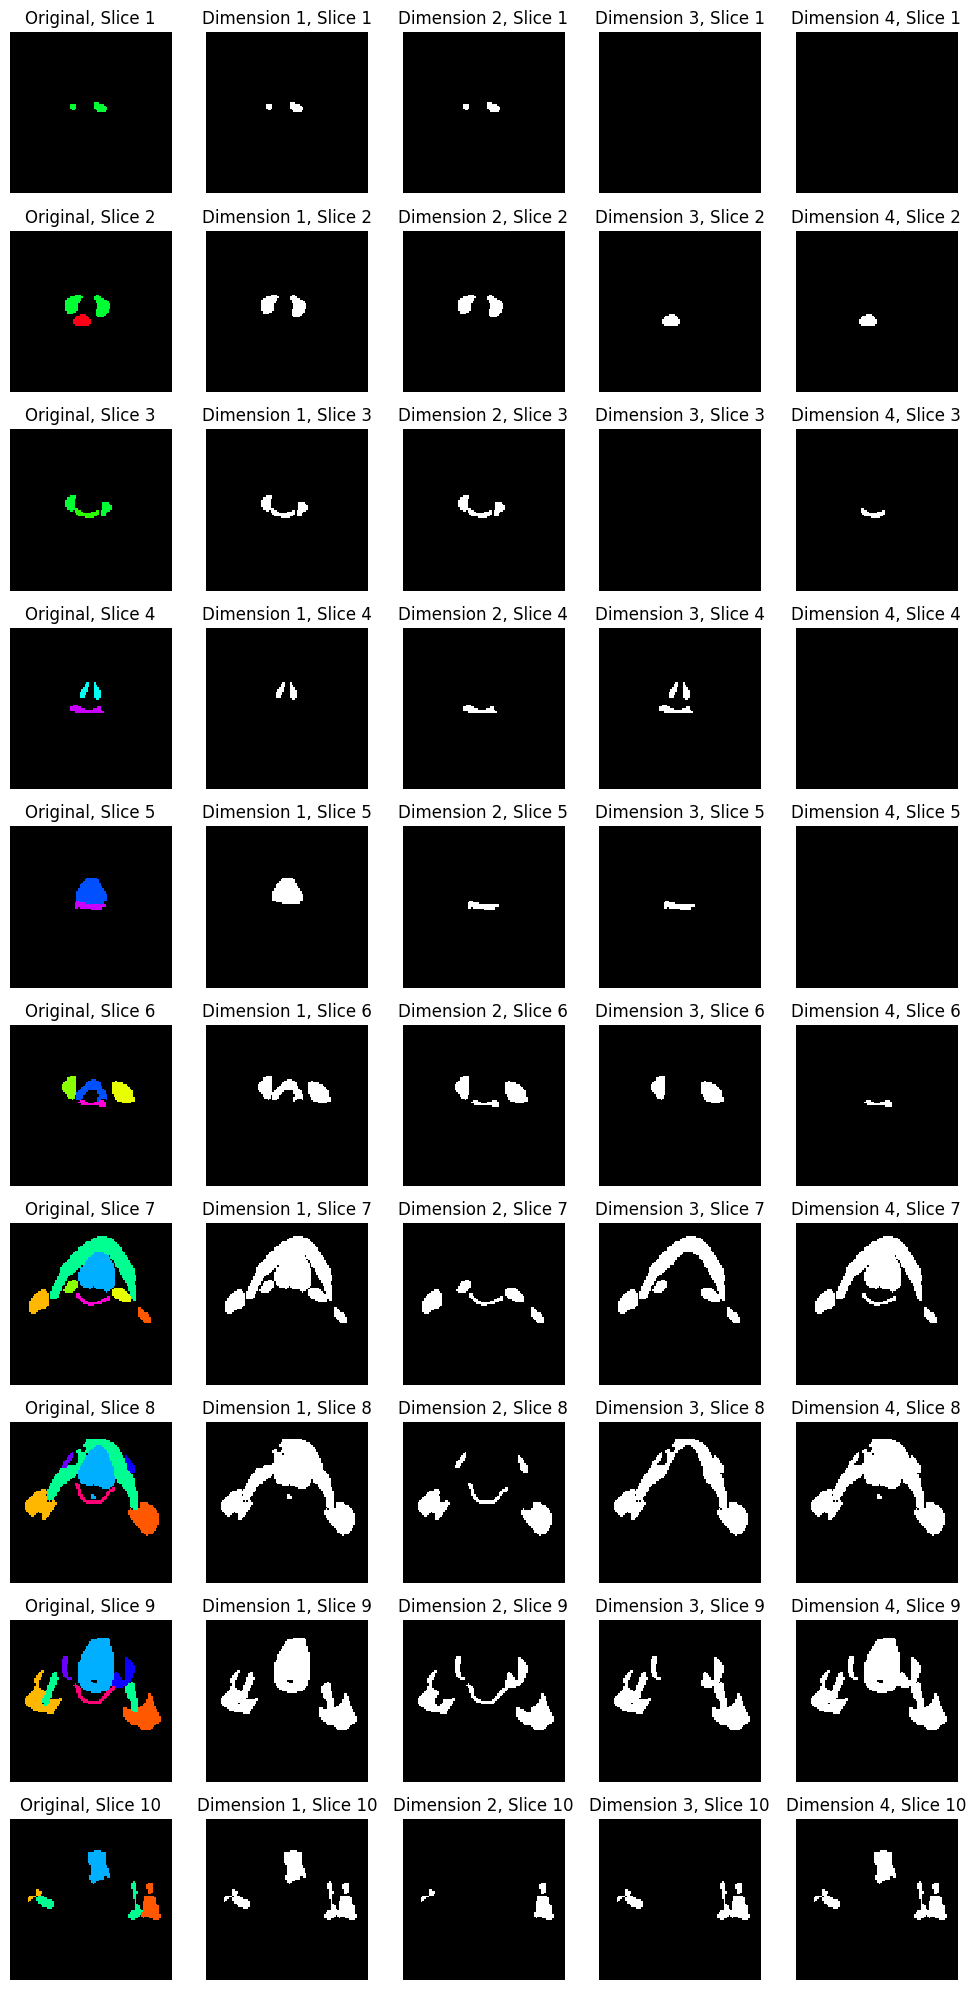

: 

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl


lower_limit = 0
upper_limit = 16
segmap_cmap = plt.cm.hsv
cmaplist = [segmap_cmap(i) for i in range(segmap_cmap.N)]
cmaplist[0] = (0, 0, 0, 1.0) # force the first color entry to be black
segmap_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'SEGMAP cmap', cmaplist, segmap_cmap.N)
bounds = np.linspace(lower_limit, upper_limit, segmap_cmap.N)
segmap_norm = mpl.colors.BoundaryNorm(bounds, segmap_cmap.N)


# Example 4D numpy array
array_4d = NEW_SEGMAP

steps = 10
stepsize = array_4d.shape[-1] // steps

width = array_4d.shape[0] + 1
height = steps

# Create a figure and a set of subplots
fig, axs = plt.subplots(height, width, figsize=(width*2, height*2)) # 10 rows, 4 columns

# Iterate over the slices and plot each one
for i, ax_row in enumerate(axs):
    for j, ax in enumerate(ax_row):
        # Select a slice from the 4D array
        if j == 0:
            slice_2d = SEGMAP[i*stepsize, :, :]
            # Plot the 2D slice
            ax.imshow(slice_2d, cmap=segmap_cmap, norm=segmap_norm, interpolation='none')
            ax.set_title(f'Original, Slice {i+1}')
        else:
            j -= 1
            slice_2d = array_4d[j, i*stepsize, :, :]
            # Plot the 2D slice
            ax.imshow(slice_2d, cmap='gray', interpolation='none')
            ax.set_title(f'Dimension {j+1}, Slice {i+1}')
        ax.axis('off') # Hide axis for cleaner look

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [48]:
NEW_SEGMAP.shape

(4, 100, 100, 100)